#Bagging & Boosting KNN & Stacking

#Question 1 : What is the fundamental idea behind ensemble techniques?how does bagging differ from boosting in terms of approach and objective?
Answer:The fundamental idea of ensemble techniques is to combine multiple models to create a more accurate and stable "super-model". Bagging builds independent models in parallel on different data subsets to reduce variance, while boosting builds models sequentially, with each new model focusing on the errors of the previous one to reduce bias.  



#Question 2: Explain how the Random Forest Classifier reduces overfitting compared to a single decision tree. Mention the role of two key hyperparameters in this process.
Answer:The Random Forest Classifier reduces overfitting compared to a single decision tree through the principles of ensemble learning, specifically bagging (Bootstrap Aggregating) and random subspace method.
How it reduces overfitting:
Bagging: Instead of training one tree on the entire dataset, Random Forest trains multiple decision trees on different random subsets of the training data, sampled with replacement (bootstrapping). This introduces diversity among the individual trees, as each tree sees a slightly different version of the data.
Random Subspace Method: At each node split within each individual tree, only a random subset of features is considered for finding the best split. This further decorrelates the trees, preventing them from relying too heavily on any single feature and making them less sensitive to noise or specific patterns in the training data.



#Question 3: What is Stacking in ensemble learning? How does it differ from traditional bagging/boosting methods? Provide a simple example use case.
Answer:  Stacking, or stacked generalization, is an ensemble learning technique that combines the predictions of multiple diverse base models using a meta-model (or final estimator) to make the ultimate prediction.

##How it differs from traditional Bagging/Boosting methods:

Heterogeneity of Base Models: Stacking typically employs heterogeneous base models (different types of algorithms like Decision Trees, Support Vector Machines, Logistic Regression, etc.), while Bagging (e.g., Random Forest) and Boosting (e.g., AdaBoost, XGBoost) usually use homogeneous weak learners (multiple instances of the same base algorithm, often decision trees).

Training Process: In Bagging, models are trained independently in parallel on bootstrapped samples of the data, and their predictions are averaged (regression) or majority-voted (classification). In Boosting, models are trained sequentially, with each subsequent model attempting to correct the errors of its predecessors. Stacking, in contrast, trains base models in parallel, and then a separate meta-model is trained on the predictions of these base models.

Focus: Bagging primarily aims to reduce variance, Boosting aims to reduce bias, and Stacking focuses on combining diverse models to achieve higher predictive accuracy by leveraging their individual strengths.
Simple Example Use Case:
Consider a problem of predicting house prices.

Base Models: Train several different base models on the house price dataset, such as:
A Linear Regression model
A Random Forest Regressor
A Gradient Boosting Regressor
A K-Nearest Neighbors Regressor
Generate Meta-features: Each of these base models will generate predictions for the house prices. These predictions from the base models become the new input features for the meta-model.

Meta-Model: Train a meta-model (e.g., a simple Ridge Regression or a Logistic Regression) using these generated "meta-features" (the predictions from the base models) to predict the final house price. The meta-model learns how to optimally weight or combine the predictions of the individual base models to produce a more accurate final prediction.



#Question 4:What is the OOB Score in Random Forest, and why is it useful? How does it help in model evaluation without a separate validation set?
Answer:  The OOB (Out-of-Bag) Score is a performance metric for Random Forest that uses samples left out during training to estimate model accuracy on unseen data without a separate validation set. It is useful because it provides a reliable and unbiased estimate of the model's generalization error, enabling model evaluation and hyperparameter tuning directly from the training data.

How is it useful for model evaluation without a separate validation set
Internal validation: The OOB samples act as a validation set, since they were not used to train the individual trees.
Estimation of generalization error: By making predictions on these unseen OOB samples, the Random Forest can estimate its performance on new data, similar to how a validation set would be used.
No need for cross-validation: This allows for model evaluation without splitting the data into separate training and validation sets, which can be particularly beneficial when data is limited.
Insight into model performance: The OOB error provides a reliable estimate of the model's generalization performance, which is crucial for assessing how well the model will perform on future, unseen data.



#Question 5: Compare AdaBoost and Gradient Boosting in terms of:
# How they handle errors from weak learners .Weight adjustment mechanism .Typical use cases
Answer: AdaBoost and Gradient Boosting are both ensemble methods that combine multiple weak learners to create a strong learner, but they differ in how they handle errors, adjust weights, and in their typical use cases.
1. How they handle errors from weak learners:
AdaBoost: AdaBoost identifies errors by tracking misclassified samples. In each iteration, it increases the weights of misclassified samples, forcing subsequent weak learners to focus more on these difficult-to-classify instances. It directly addresses the classification error of the previous learner.
Gradient Boosting: Gradient Boosting handles errors by fitting subsequent weak learners to the residuals (the difference between the actual values and the predictions of the current ensemble) of the previous models. It aims to minimize a differentiable loss function using gradient descent, effectively learning from the "errors" in the form of negative gradients.

2. Weight adjustment mechanism:
AdaBoost: AdaBoost adjusts the weights of the training samples. Misclassified samples receive higher weights, making them more influential in the training of the next weak learner. Additionally, each weak learner in the final ensemble is assigned a weight based on its accuracy, with more accurate learners having a greater influence on the final prediction.
Gradient Boosting: Gradient Boosting does not directly adjust sample weights in the same way as AdaBoost. Instead, it builds an additive model where each new weak learner is trained on the residuals of the previous model. The contribution of each new learner to the overall model is scaled by a learning rate, which acts as a form of weight adjustment for the contribution of each weak learner rather than the samples themselves.

3. Typical use cases:
AdaBoost: AdaBoost is primarily known for its effectiveness in binary classification tasks, such as face detection, spam detection, and medical diagnosis. It performs well with clean data but can be sensitive to noisy data and outliers due to its aggressive weighting mechanism.
Gradient Boosting: Gradient Boosting is more flexible and can be applied to a wider range of problems, including regression, multi-class classification, and ranking problems. It is particularly well-suited for complex datasets with non-linear relationships and is less sensitive to noisy data than AdaBoost because it smooths updates using gradients. Popular implementations like XGBoost, LightGBM, and CatBoost have made it a go-to algorithm for various machine learning competitions and real-world applications.



#Question 6:Why does CatBoost perform well on categorical features without requiring extensive preprocessing? Briefly explain its handling of categorical variables.
Answer:  CatBoost performs well on categorical features without extensive preprocessing primarily because of its innovative techniques: Ordered Target Encoding and Ordered Boosting. These methods efficiently convert categorical variables to numerical values during training while preventing the target leakage that often causes overfitting in other gradient boosting algorithms.

Handling of categorical variables
Ordered Target Encoding
This is the core technique CatBoost uses to handle high-cardinality categorical features. It avoids target leakage, where the model uses information from the target variable to encode categorical features, leading to overly optimistic results on the training set.

Permutation: Before constructing each new tree, CatBoost creates a random permutation (ordering) of the training dataset.
Sequential Calculation: For each row in the dataset, the categorical feature is converted to a numerical value based on the target statistics (e.g., the average target value) of only the preceding rows in that random permutation.
Prior and Noise: To prevent the model from overfitting to specific categories with only a few previous samples, CatBoost includes a prior value in its calculation. This makes the encoding more robust.



#Question 7: KNN Classifier Assignment: Wine Dataset Analysis with
#Optimization
Task:
1. Load the Wine dataset (sklearn.datasets.load_wine()).
2. Split data into 70% train and 30% test.
3. Train a KNN classifier (default K=5) without scaling and evaluate using:
a. Accuracy
b. Precision, Recall, F1-Score (print classification report)
4. Apply StandardScaler, retrain KNN, and compare metrics.
5. Use GridSearchCV to find the best K (test K=1 to 20) and distance metric
(Euclidean, Manhattan).
6. Train the optimized KNN and compare results with the unscaled/scaled versions.


In [1]:
pip install scikit-learn

In [2]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


In [3]:

# ⿡ Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

In [4]:
# ⿢ Split data into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ⿣ Train KNN classifier (default K=5) without scaling
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


In [5]:
print("🔹Without Scaling:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


🔹Without Scaling:
Accuracy: 0.7407407407407407
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.75      0.71      0.73        21
           2       0.53      0.57      0.55        14

    accuracy                           0.74        54
   macro avg       0.73      0.73      0.73        54
weighted avg       0.74      0.74      0.74        54



In [6]:
# ⿤ Apply StandardScaler, retrain KNN and compare metrics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)


In [7]:

print("\n🔹With StandardScaler:")
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))



🔹With StandardScaler:
Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



In [8]:
# ⿥ Use GridSearchCV to find best K (1–20) and best distance metric
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20]},
             scoring='accuracy')

In [9]:
print("\n🔹Best Parameters from GridSearchCV:")
print(grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)



🔹Best Parameters from GridSearchCV:
{'metric': 'manhattan', 'n_neighbors': 1}
Best Cross-Validation Accuracy: 0.9753333333333334


In [12]:

# ✅ Evaluate final model with best parameters
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)


In [14]:
print("\n🔹Final Evaluation with Best Parameters:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, ))y_pred_best


🔹Final Evaluation with Best Parameters:
Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



In [17]:

# ⿦ Train the optimized KNN and compare results
best_knn = grid.best_estimator_
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)


In [20]:

print("\n🔹 Optimized KNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test,y_pred_best))


🔹 Optimized KNN Results:
Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



#Question 8 : PCA + KNN with Variance Analysis and Visualization
Task:
1. Load the Breast Cancer dataset (sklearn.datasets.load_breast_cancer()).
2. Apply PCA and plot the scree plot (explained variance ratio).
3. Retain 95% variance and transform the dataset.
4. Train KNN on the original data and PCA-transformed data, then compare
accuracy.
5. Visualize the first two principal components using a scatter plot (color by class).*italicised text*

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [23]:

# ⿡ Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target


In [24]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


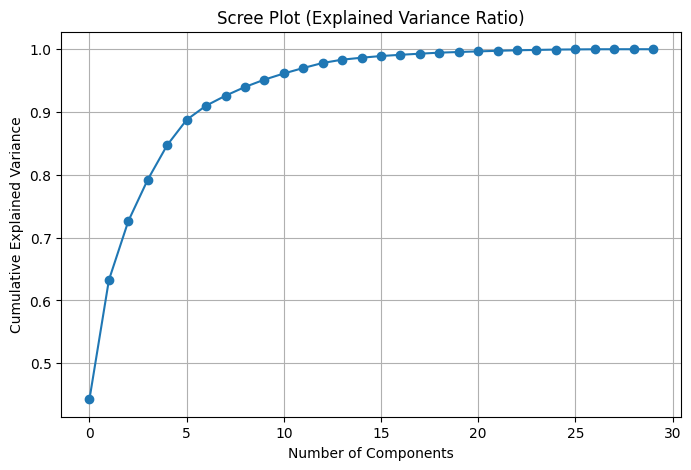

In [25]:

# ⿢ Apply PCA and plot the scree plot (explained variance ratio)
pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot (Explained Variance Ratio)')
plt.grid(True)
plt.show()

In [26]:
# ⿣ Retain 95% variance and transform the dataset
pca_95 = PCA(0.95)
X_pca = pca_95.fit_transform(X_scaled)
print(f"Number of components retained: {pca_95.n_components_}")


Number of components retained: 10


In [28]:

# ⿤ Train KNN on the original and PCA-transformed data, compare accuracy
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Original data
knn_original = KNeighborsClassifier(n_neighbors=5)
knn_original.fit(X_train, y_train)
y_pred_original = knn_original.predict(X_test)
acc_original = accuracy_score(y_test, y_pred_original)


In [29]:

# PCA-transformed data
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.2, random_state=42)
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)


In [30]:
print(f"Accuracy on Original Data: {acc_original:.4f}")
print(f"Accuracy on PCA Data (95% variance): {acc_pca:.4f}")

Accuracy on Original Data: 0.9474
Accuracy on PCA Data (95% variance): 0.9561


In [31]:
# ⿥ Visualize the first two principal components (scatter plot color by class)
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)



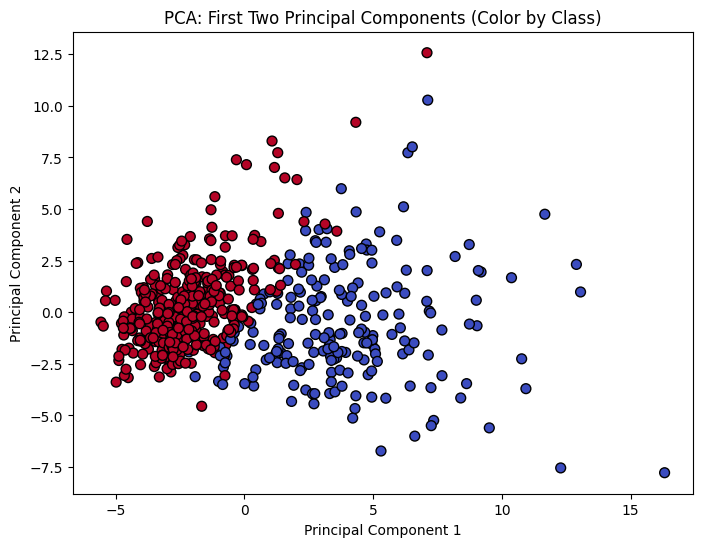

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First Two Principal Components (Color by Class)')
plt.show()

#Question 9:KNN Regressor with Distance Metrics and K-Value Analysis
Task:
1. Generate a synthetic regression dataset
(sklearn.datasets.make_regression(n_samples=500, n_features=10)).
2. Train a KNN regressor with:
a. Euclidean distance (K=5)
b. Manhattan distance (K=5)
c. Compare Mean Squared Error (MSE) for both.
3. Test K=1, 5, 10, 20, 50 and plot K vs. MSE to analyze bias-variance tradeoff.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [36]:
# ⿡ Generate synthetic regression dataset
X, y = make_regression(n_samples=500, n_features=10, noise=15, random_state=42)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Define distance metrics to compare
distance_metrics = ['euclidean', 'manhattan']

# Store results for plotting
results = {}



In [37]:

# ⿢ Train and test KNN Regressor with both distance metrics
for metric in distance_metrics:
    mse_values = []
    k_values = [1, 5, 10, 20, 50]
    for k in k_values:
        model = KNeighborsRegressor(n_neighbors=k, metric=metric)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mse_values.append(mse)
    results[metric] = mse_values


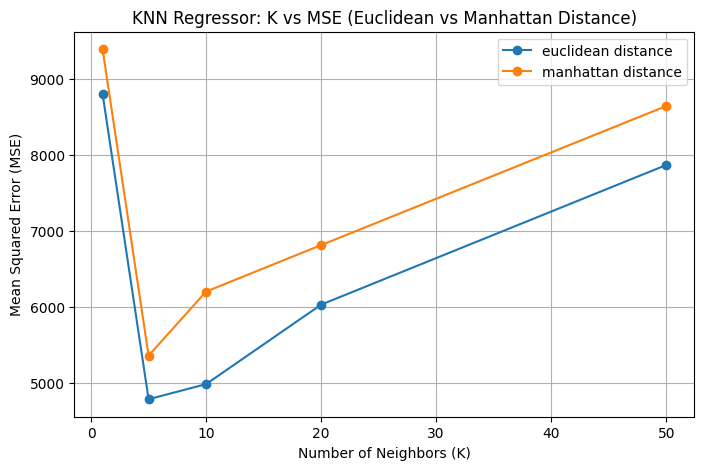

In [38]:
# ⿣ Plot results: K vs MSE for both distance metrics
plt.figure(figsize=(8,5))
for metric in distance_metrics:
    plt.plot([1,5,10,20,50], results[metric], marker='o', label=f"{metric} distance")

plt.title("KNN Regressor: K vs MSE (Euclidean vs Manhattan Distance)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.grid(True)
plt.show()

#Question 10: KNN with KD-Tree/Ball Tree, Imputation, and Real-World Data
Task:
1. Load the Pima Indians Diabetes dataset (contains missing values).
2. Use KNN Imputation (sklearn.impute.KNNImputer) to fill missing values.
3. Train KNN using:
a. Brute-force method
b. KD-Tree
c. Ball Tree
4. Compare their training time and accuracy.
5. Plot the decision boundary for the best-performing method (use 2 most important
features).

In [39]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [40]:

# 1. Load the Pima Indians Diabetes Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv(url, names=columns)


In [41]:

print("Initial Data:")
print(df.head())
print("\nMissing values before imputation:")
print((df == 0).sum())


Initial Data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing values before imputation:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           

In [43]:
# 2. Use KNN imputation to fill missing values
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=columns)


In [45]:

# Split data
X = df_imputed.drop('Outcome', axis=1)
y = df_imputed['Outcome']


In [46]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [47]:
# 3. Train KNN using Brute-force, KD-Tree, and Ball Tree
algorithms = ['brute', 'kd_tree', 'ball_tree']
results = {}

for algo in algorithms:
    start = time.time()
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    knn.fit(X_train, y_train)
    end = time.time()


In [48]:
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[algo] = {'accuracy': acc, 'time': end - start}


In [49]:
# 4. Compare training time and accuracy
print("\nComparison of KNN Algorithms:")
for algo, metrics in results.items():
    print(f"{algo.upper()}: Accuracy = {metrics['accuracy']:.4f}, Time = {metrics['time']:.4f} sec")



Comparison of KNN Algorithms:
BALL_TREE: Accuracy = 0.6883, Time = 0.0033 sec


In [50]:

# 5. Plot decision boundary for best performing model (using top 2 features)
best_algo = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest Performing Algorithm: {best_algo.upper()}")



Best Performing Algorithm: BALL_TREE


In [51]:
# Use two most important features for visualization
feature_importance = pd.Series(np.var(X_scaled, axis=0), index=X.columns).sort_values(ascending=False)
top2 = feature_importance.index[:2]
print(f"Using top 2 features: {list(top2)}")


Using top 2 features: ['Pregnancies', 'Glucose']


In [53]:

X2 = df_imputed[top2]
X2_scaled = scaler.fit_transform(X2)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2_scaled, y, test_size=0.2, random_state=42)


knn_best = KNeighborsClassifier(n_neighbors=5, algorithm=best_algo)
knn_best.fit(X_train2, y_train2)



KNeighborsClassifier(algorithm='ball_tree')

In [54]:

# Plot decision boundary
h = 0.02
x_min, x_max = X2_scaled[:, 0].min() - 1, X2_scaled[:, 0].max() + 1
y_min, y_max = X2_scaled[:, 1].min() - 1, X2_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn_best.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


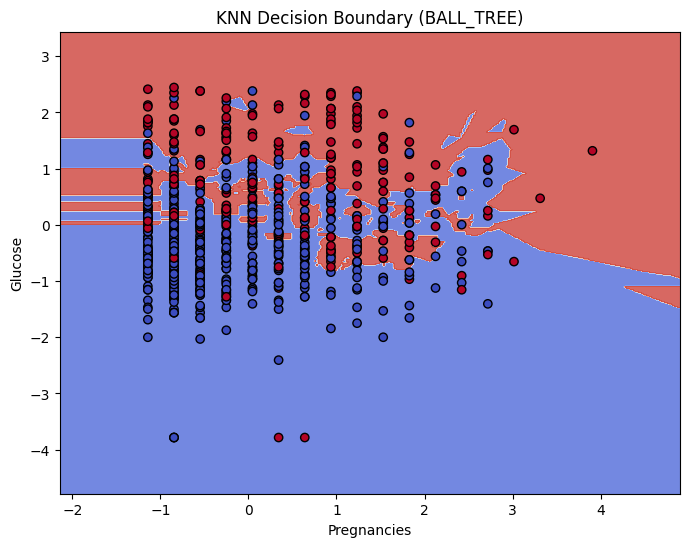

In [55]:

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.xlabel(top2[0])
plt.ylabel(top2[1])
plt.title(f"KNN Decision Boundary ({best_algo.upper()})")
plt.show()